In [21]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('science')
plt.rcParams['text.usetex'] = True
#import seaborn; seaborn.set()
import astropy.io.fits as fits
from astropy.io import ascii
from astropy.table import Table
import scipy.stats as stats
import os
import re
from pandas import DataFrame
import pandas as pd
import sys
# 定义颜色
colors = {
    'red': '#E24A33',
    'blue': '#348ABD',
    'green': '#8EBA42',
    'orange': '#FBC15E',
    'purple': '#988ED5',
    'pink': '#FFB5B8',
    'gray': '#777777'
}
plt.rcParams.update({
    'font.size': 12,               # 字体大小
    'font.family': 'sans-serif',    # 字体类型
    'font.sans-serif': ['Arial'],   # 使用 Arial 字体
    'axes.linewidth': 1.5,          # 坐标轴线宽
    'axes.labelsize': 14,           # 坐标轴标签大小
    'axes.titlesize': 14,           # 标题字体大小
    'xtick.labelsize': 12,          # X轴刻度字体大小
    'ytick.labelsize': 12,          # Y轴刻度字体大小
    'xtick.major.size': 5,          # X轴主刻度长度
    'ytick.major.size': 5,          # Y轴主刻度长度
    'xtick.major.width': 1.5,       # X轴主刻度宽度
    'ytick.major.width': 1.5,       # Y轴主刻度宽度
    'legend.fontsize': 12,          # 图例字体大小
    'legend.frameon': False,        # 图例无边框
    'lines.linewidth': 1.5,         # 曲线的默认线宽
    'savefig.dpi': 300,             # 保存图片的分辨率
    'figure.figsize': (7, 5),       # 图形大小 (以英寸为单位)
    'figure.autolayout': False       # 自动调整布局
})

def readfile(tfile): 
    with open(tfile,'r') as f:
        lines=f.readlines()
    return lines

In [33]:
source="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/HHT/20201120_QPOphase/fit_results_cyclabs"
path0="/Volumes/WD_BLACK/Data/1A0535p262/HXMT/HHT/20201120_QPOphase/fit_results_cyclabs"
files=os.listdir("%s"%source)

In [34]:
# Models=['gabs','gaussian','fdcut']
# N_Units=[[1,1],[0],[0,0,0,0]]
# errs=[3,5,8,9,10,11,12]
# Long_index=[1,1,1]

# Models=['gabs','gabs','gaussian','fdcut']
# N_Units=[[1,1],[1,1,1],[0],[0,0,0,0]]
# errs=[3,5,6,7,8,11,12,13,14,15]
# Long_index=[2,1,1,1]

# Models=['gabs','gabs','bbodyrad','compmag']
# N_Units=[[1,1],[1,1,1],[0],[1,0]]
# errs=[ 2,4,5,6,7,10,15,22]
# Long_index=[2,1,1,1]

# Models=['gabs','gabs','bbodyrad','compmag']
# N_Units=[[1,1],[1,1,1],[0],[1,0]]
# errs=[ 2,4,5,6,7,10,15,22]
# Long_index=[2,1,1,1]

Models=['cyclabs','cyclabs','gaussian','fdcut']
N_Units=[[0,1],[0,1],[0],[0,0,0,0]]
errs=[2,3,7,8,15,16,17,18,19] 
Long_index=[2,1,1,1]

# Models=['mgabs','gaussian','NPEX']
# N_Units=[[0,0,0],[0],[0,0,0,0]]
# errs=[2,3,5,11,13,14,15,16] 
# Long_index=[1,1,1]

# Models=['gabs','fdcut']
# N_Units=[[1,1,1],[0,0,0,0]]
# errs=[3,4,5,9,10,11,12]
# Long_index=[1,1]


In [35]:
def read_fitresults(source,files,Models,N_Unitsi,path0):
    print(files)
    #MJD = read_MJD(files,path0)
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    #print(line_tails)
    j=0
    pars_values=[]
    pars_names=[]
    while j < len(Models):
        pars=re.findall(r"%s.*"%Models[j], all)
        #print(pars)
        l=len(N_Units[j])
        while l > 0:
            p=N_Units[j][-l]
            if Long_index[j] > 1:
                pars_values.append(float(pars[-l-(Long_index[j]-1)*len(N_Units[j+1])].split()[2+p]))
                #print(pars_values)
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
            else:
                pars_values.append(float(pars[-l].split()[2+p]))
                name_str=Models[j]+'%s'%Long_index[j]+'_'+pars[-l].split()[1]
                pars_names.append(name_str)
                l-=1
        j+=1
    par_chi=re.findall(r"Test statistic : Chi-Squared.*", all)
    #print(par_chi[-1].split())
    dofall=re.findall(r"Null hypothesis probability.*", all)
    #print(dofall[-1].split())
    chi2=par_chi[-1].split()[4]
    # print(chi2)
    dof=dofall[-1].split()[6]
    # print(dof)
    red_chi2=float(chi2)/float(dof)
    # print(red_chi2)
    return pars_names, pars_values, red_chi2

In [36]:
def read_errs(source,files,errs,pars_names,pars_values):
    f = open("%s/%s"%(source,files),"r")
    all=f.read()
    #print(all)
    line_tails=readfile("%s/%s"%(source,files))
    Err=re.findall(r"Parameter   Credible Interval.*", all)
    l=0
    while l < len(line_tails):
        if Err[0] in line_tails[l]:
            L=l
        else:
            pass
        l+=1
    for e in errs:
        Errs_results=[line_tails[L+1+a].split() for a in range(len(errs))]
    pars_Err_lh=[]
    NE=0
    while NE < len(errs):
        err_low=float(Errs_results[NE][1])
        err_high=float(Errs_results[NE][2])
        pars_Err_lh.append([err_low,err_high])
        NE+=1
    #print(pars_values)
    #get err
    Np=0
    err_LR=[]
    while Np < len(pars_values):
        err_L=pars_values[Np]-pars_Err_lh[Np][0]
        err_R=pars_Err_lh[Np][1]-pars_values[Np]
        err_LR.append([err_L,err_R])
        Np+=1
    err_names_L=["%s_Lerrs"%Name for Name in pars_names]
    err_names_R=["%s_Rerrs"%Name for Name in pars_names]

    err_L=[i[0] for i in err_LR]
    err_R=[i[1] for i in err_LR]

    return err_names_L,err_L,err_names_R,err_R

In [37]:
i=0
red_chi2_all=[]
while i < len(files):
#while i < 1:
    #pars_names, pars_values,red_chi2,dof, MJD, Lum, Lum_errL, Lum_errR=read_fitresults(source,files[i],Models,N_Units,path0)
    pars_names, pars_values, red_chi2=read_fitresults(source,files[i],Models, N_Units,path0)
    red_chi2_all.append(red_chi2)
    #print(red_chi2)
    #print(pars_names)
    fit_names=pars_names
    fit_data=pars_values

    err_names_L, err_L, err_names_R, err_R=read_errs(source,files[i],errs,pars_names,pars_values)
    #print(err_names_L)
    #err_names_L, err_L = err_names_L+['Lum_errL'], err_L+[Lum_errL]
    #err_names_R, err_R = err_names_R+['Lum_errR'], err_R+[Lum_errR]
    
    derr_L=dict(zip(err_names_L,err_L))
    derr_R=dict(zip(err_names_R,err_R))
    if i==0:
        d1 = dict(zip(fit_names,fit_data))
        Para=pd.DataFrame(d1,index=['%s'%files[i]])
        Para_errL=pd.DataFrame(derr_L,index=['%s'%files[i]])
        Para_errR=pd.DataFrame(derr_R,index=['%s'%files[i]])
        i+=1
    else:
        #print(files[i])
        Para.loc['%s'%files[i]]=fit_data
        Para_errL.loc['%s'%files[i]]=err_L
        Para_errR.loc['%s'%files[i]]=err_R
        i+=1
Para_all=pd.concat([Para,Para_errL,Para_errR],axis=1)
#save_data="fit_comptt_final.csv"
#Para_all.to_csv(save_data)

phase_0001.txt
phase_0102.txt
phase_0203.txt
phase_0304.txt
phase_0405.txt
phase_0506.txt
phase_0607.txt
phase_0708.txt
phase_0809.txt
phase_0910.txt


In [38]:
Para_all

,cyclabs2_Depth0,cyclabs2_E0,cyclabs1_Depth0,cyclabs1_E0,gaussian1_norm,fdcut1_Gamma1,fdcut1_Ecut,fdcut1_Efold,fdcut1_norm,cyclabs2_Depth0_Lerrs,...,fdcut1_norm_Lerrs,cyclabs2_Depth0_Rerrs,cyclabs2_E0_Rerrs,cyclabs1_Depth0_Rerrs,cyclabs1_E0_Rerrs,gaussian1_norm_Rerrs,fdcut1_Gamma1_Rerrs,fdcut1_Ecut_Rerrs,fdcut1_Efold_Rerrs,fdcut1_norm_Rerrs
phase_0001.txt,0.302357,109.289,0.297809,40.8650,0.058493,0.448639,11.6754,11.9530,2.25835,0.188816,...,0.03369,0.197175,5.498,0.021003,0.4419,0.004490,0.011582,0.9123,0.0253,0.02626
phase_0102.txt,0.410150,109.275,0.253810,38.7156,0.062048,0.487567,14.4072,11.9557,2.19763,0.188375,...,0.01686,0.337117,8.548,0.017802,0.2153,0.008124,0.009541,0.5070,0.0585,0.02192
phase_0203.txt,0.796762,106.934,0.163887,37.4926,0.050340,0.509697,15.3565,12.2696,2.21347,0.105972,...,0.01985,0.296638,4.425,0.014410,0.8006,0.003927,0.008272,0.6249,0.0904,0.02992
phase_0304.txt,0.625937,101.835,0.152641,35.7420,0.054489,0.549041,19.2351,12.2231,2.16708,0.096118,...,0.02262,0.130292,3.338,0.019444,0.7620,0.003811,0.009694,0.6457,0.1090,0.02341
phase_0405.txt,0.725494,102.652,0.143732,35.7219,0.059362,0.554845,20.1777,12.3007,2.17591,0.128742,...,0.02103,0.117690,2.641,0.018156,0.6638,0.005799,0.006173,0.7618,0.0810,0.01786
phase_0506.txt,0.872975,104.524,0.126707,35.5346,0.062855,0.544546,18.9926,12.4316,2.21749,0.152932,...,0.02418,0.168055,2.335,0.023634,1.0049,0.005438,0.014741,1.0440,0.0858,0.01647
phase_0607.txt,0.603208,105.372,0.180347,36.6188,0.054268,0.515060,17.1272,12.3086,2.19043,0.100118,...,0.02742,0.250374,5.376,0.015652,0.5693,0.008726,0.010764,0.8549,0.0927,0.02919
phase_0708.txt,0.581574,109.991,0.235213,38.1475,0.055604,0.484629,14.9625,12.1733,2.19726,0.094940,...,0.01714,0.413054,6.956,0.008914,0.3057,0.005076,0.010201,0.6302,0.0909,0.02838
phase_0809.txt,0.420471,112.141,0.284993,40.0263,0.055034,0.450135,12.7650,11.9889,2.24813,0.236562,...,0.02790,0.177082,4.932,0.026581,0.3296,0.003902,0.009519,0.6053,0.0634,0.02255
phase_0910.txt,0.147446,113.079,0.321747,40.7356,0.059247,0.440712,11.6915,11.8604,2.27896,0.126081,...,0.01555,0.181530,5.950,0.018599,0.5031,0.004613,0.011096,0.7774,0.0849,0.03443


In [39]:
red_chi2_all=np.array(red_chi2_all)
red_chi2_all

array([1.19438119, 1.06283767, 0.9892698 , 0.91879012, 1.00939506,
       1.03309842, 1.00965644, 1.05789281, 1.06862195, 1.36023171])

In [40]:
# array([1.02469291, 1.04010963, 1.00483516, 0.98260734, 1.03002324,
#        1.00123267, 0.96921947, 1.0378577 , 1.0424181 , 1.03605942])
# array([1.05194988, 1.0372352 , 1.00356753, 1.00218944, 1.05700308,
#        1.01504215, 0.97053036, 1.04151538, 1.05785881, 1.04276827])
# array([1.12392801, 1.05589883, 1.00779251, 1.07849496, 1.1295535 ,
#        1.07886677, 0.97735023, 1.05447348, 1.11148837, 1.12940948])

In [41]:
print(Para_all.columns)
M=len(errs)
print(M)
names=Para_all.columns[:M]
print(names)

Index(['cyclabs2_Depth0', 'cyclabs2_E0', 'cyclabs1_Depth0', 'cyclabs1_E0',
       'gaussian1_norm', 'fdcut1_Gamma1', 'fdcut1_Ecut', 'fdcut1_Efold',
       'fdcut1_norm', 'cyclabs2_Depth0_Lerrs', 'cyclabs2_E0_Lerrs',
       'cyclabs1_Depth0_Lerrs', 'cyclabs1_E0_Lerrs', 'gaussian1_norm_Lerrs',
       'fdcut1_Gamma1_Lerrs', 'fdcut1_Ecut_Lerrs', 'fdcut1_Efold_Lerrs',
       'fdcut1_norm_Lerrs', 'cyclabs2_Depth0_Rerrs', 'cyclabs2_E0_Rerrs',
       'cyclabs1_Depth0_Rerrs', 'cyclabs1_E0_Rerrs', 'gaussian1_norm_Rerrs',
       'fdcut1_Gamma1_Rerrs', 'fdcut1_Ecut_Rerrs', 'fdcut1_Efold_Rerrs',
       'fdcut1_norm_Rerrs'],
      dtype='object')
9
Index(['cyclabs2_Depth0', 'cyclabs2_E0', 'cyclabs1_Depth0', 'cyclabs1_E0',
       'gaussian1_norm', 'fdcut1_Gamma1', 'fdcut1_Ecut', 'fdcut1_Efold',
       'fdcut1_norm'],
      dtype='object')


In [42]:
# 20201120
phase_bins=np.array([0.0626961 , 0.12518171, 0.18766732, 0.25015293, 0.31263853,
        0.37512414, 0.43760975, 0.50009536, 0.56258097, 0.62506658,
        0.68755218, 0.75003779, 0.8125234 , 0.87500901, 0.93749462,
        0.99998022, 1.0626961 , 1.12518171, 1.18766732, 1.25015293,
        1.31263853, 1.37512414, 1.43760975, 1.50009536, 1.56258097,
        1.62506658, 1.68755218, 1.75003779, 1.8125234 , 1.87500901,
        1.93749462, 1.99998022])
profile=np.array([4581.67724052, 4610.92033798, 4860.12465291, 5068.81297456,
        5393.86217149, 5747.60199984, 5962.29789586, 6057.82552249,
        6048.60594215, 5912.43659947, 5574.53876438, 5355.41892312,
        5147.6729164 , 4965.21713747, 4742.3547959 , 4660.97259794,
        4581.67724052, 4610.92033798, 4860.12465291, 5068.81297456,
        5393.86217149, 5747.60199984, 5962.29789586, 6057.82552249,
        6048.60594215, 5912.43659947, 5574.53876438, 5355.41892312,
        5147.6729164 , 4965.21713747, 4742.3547959 , 4660.97259794])



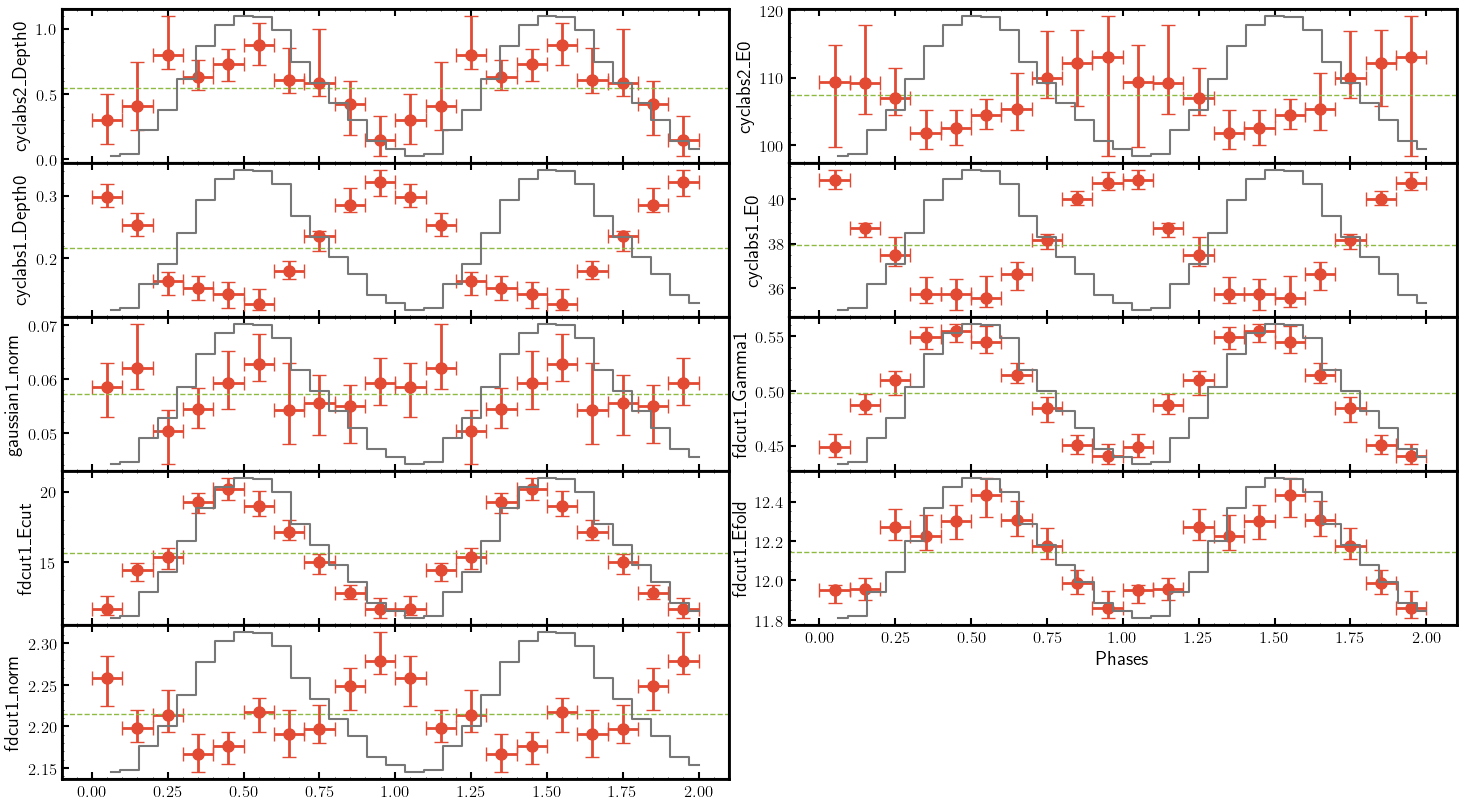

In [56]:
X = np.array([0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95])
x_data=np.hstack([X,X+1])
X_err=np.array([0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05])
x_err=np.hstack([X_err,X_err])
fig, axs = plt.subplots((M)//2+1, 2, figsize=(18, 10))
axs = axs.flatten()
#fig, axs = plt.subplots(M+1,1,figsize=(4, 16))
Ylabels=names
# Ylabels=[r'$E_{\rm cyc2}$ [keV]',r'$S_{\rm cyc2}$ [keV]', 
#          r'$E_{\rm cyc1}$ [keV]', r'$\sigma_{\rm cyc1}$ [keV]', r'$S_{\rm cyc1}$ [keV]', 
#          r'$I_{\rm Fe}$', 
#          r'$\Gamma$', r'$E_{\rm cut}$ [keV]', r'$E_{\rm fold}$ [keV]', r'Norm']
i=0
while i < len(names):
    name=names[i]
    y1=Para_all['%s'%name].values
    #print(np.mean(y1))
    y1_err=[abs(Para_all['%s_Lerrs'%name].values),abs(Para_all['%s_Rerrs'%name].values)]
    y1=np.hstack([y1,y1])
    #y1=abs(y1)
    y1_err=np.hstack([y1_err,y1_err])
    y1_err=abs(y1_err)
    axs[0+i].errorbar(x_data, y1, xerr=x_err, yerr=y1_err, 
                      fmt='o', color=colors['red'], ecolor=colors['red'], capsize=5, markersize=8, elinewidth=2)
    axs[0+i].axhline(y=np.mean(y1), color=colors['green'], linestyle='--', lw=1)
    axs2 = axs[0+i].twinx()
    axs2.errorbar(phase_bins, profile/np.mean(profile), 
                  drawstyle='steps-mid',color=colors['gray'],ecolor=colors['gray'])
    #axs2.errorbar(phase_bins2, profile2/np.mean(profile2), drawstyle='steps-mid',color='b',ecolor='b',alpha=0.5)
    axs2.set_yticks([])
    axs[0+i].set_ylabel(Ylabels[i],fontsize=14, fontweight='bold',fontname='Times New Roman')
    axs[i].spines['top'].set_linewidth(2)
    axs[i].spines['right'].set_linewidth(2)
    axs[i].spines['bottom'].set_linewidth(2)
    axs[i].spines['left'].set_linewidth(2)
    i+=1
#plot reduced chi^2 of fitting: 
axs[0+i].errorbar(x_data,np.hstack([red_chi2_all,red_chi2_all]),fmt='.',color=colors['red'],ecolor=colors['red'])
axs[0+i].axhline(y=1, color=colors['green'], linestyle='--',lw=1)
#axs[0+i].set_ylim(0.7,1.3)
#axs[0+i].set_xlim(0.0,2.0)
#设置边框
axs[i].spines['top'].set_linewidth(2)
axs[i].spines['right'].set_linewidth(2)
axs[i].spines['bottom'].set_linewidth(2)
axs[i].spines['left'].set_linewidth(2)
# 移除最后一个子图
fig.delaxes(axs[-1])
axs[-3].set_xlabel('Phases',fontsize=14, fontweight='bold',fontname='Times New Roman')
axs[0+i].set_ylim(0.7,1.3)
axs[0+i].set_ylabel(r'$\chi^2_{\rm red}$',fontsize=14, fontweight='bold',fontname='Times New Roman')
axs[0+i].set_xlabel('Phases',fontsize=14, fontweight='bold',fontname='Times New Roman')

plt.subplots_adjust(wspace=0.09,hspace=0)
plt.savefig('20201120_cyclabs.pdf')

In [45]:
for i in names:
    rms=100*(max(abs(Para_all[i].values))-(min(abs(Para_all[i].values))))/(abs(max(Para_all[i].values))+min(abs(Para_all[i].values)))
    K=np.mean(Para_all[i].values)
    #print('rms:',rms)
    print('mean:',i,K)

mean: cyclabs2_Depth0 0.5486374
mean: cyclabs2_E0 107.5092
mean: cyclabs1_Depth0 0.21608860000000002
mean: cyclabs1_E0 37.95998999999999
mean: gaussian1_norm 0.05717395000000001
mean: fdcut1_Gamma1 0.4984871
mean: fdcut1_Ecut 15.639069999999995
mean: fdcut1_Efold 12.14649
mean: fdcut1_norm 2.214471


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as stats

# =========================
# Models
# =========================
def const_func(x, C):
    return C

def sin_func(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C


# =========================
# Main analysis (stats on 0–1, plot on 0–2)
# =========================
name0 = "cyclabs1_E0"

# ---------
# 0) Load your real data from Para_all (must exist in your environment)
# ---------
y_01 = Para_all[name0].values
yerrL_01 = np.abs(Para_all[f"{name0}_Lerrs"].values)
yerrR_01 = np.abs(Para_all[f"{name0}_Rerrs"].values)

# Use symmetric error for chi2 / curve_fit weights
yerr_01 = 0.5 * (yerrL_01 + yerrR_01)

# ---------
# 1) Independent phase bins for statistics: 0–1
# ---------
N = len(y_01)
# If you already have your own phase bin centers (recommended), use them:
# x_01 = phase_bins   # must be length N and within [0,1)
# Otherwise, fall back to uniform bins:
x_01 = np.linspace(0, 1, N, endpoint=False)

# ---------
# 2) Fit constant model (0–1 only)
# ---------
params_const, cov_const = curve_fit(
    const_func, x_01, y_01,
    sigma=yerr_01, absolute_sigma=True
)
y_fit_const_01 = const_func(x_01, *params_const)
chi2_const = np.sum(((y_01 - y_fit_const_01) / yerr_01) ** 2)
dof_const = len(y_01) - len(params_const)  # len(params_const)=1

# ---------
# 3) Fit sinusoidal model (0–1 only)
# ---------
# Good initial guesses help a lot:
A0 = 0.5 * (np.nanmax(y_01) - np.nanmin(y_01)) if np.isfinite(y_01).all() else 1.0
C0 = np.nanmean(y_01)
omega0 = 2 * np.pi  # one cycle per phase
phi0 = 0.0

params_sin, cov_sin = curve_fit(
    sin_func, x_01, y_01,
    sigma=yerr_01, absolute_sigma=True,
    p0=[A0, omega0, phi0, C0],
    maxfev=20000
)
y_fit_sin_01 = sin_func(x_01, *params_sin)
chi2_sin = np.sum(((y_01 - y_fit_sin_01) / yerr_01) ** 2)
dof_sin = len(y_01) - len(params_sin)  # len(params_sin)=4

# ---------
# 4) F-test: compare nested models (0–1 only)
# ---------
delta_dof = dof_const - dof_sin  # should be 3
if delta_dof <= 0:
    raise ValueError(f"delta_dof must be > 0, got {delta_dof}")

F_value = ((chi2_const - chi2_sin) / delta_dof) / (chi2_sin / dof_sin)
p_value = 1 - stats.f.cdf(F_value, delta_dof, dof_sin)

# Convert p -> Gaussian-equivalent "sigma" (one-sided)
# (If p_value is extremely tiny, guard numerical issues)
p_value = np.clip(p_value, 1e-300, 1.0)
z_score = stats.norm.ppf(1 - p_value)

print(f"chi2 (constant model): {chi2_const:.2f}")
print(f"Degrees of freedom (constant model): {dof_const}")
print(f"chi2 (sin model): {chi2_sin:.2f}")
print(f"Degrees of freedom (sin model): {dof_sin}")
print(f"F value: {F_value:.2f}")
print(f"p value: {p_value:.6e}")
print(f"Significance (one-sided): {z_score:.2f} sigma")


chi2 (constant model): 149.14
Degrees of freedom (constant model): 9
chi2 (sin model): 3.02
Degrees of freedom (sin model): 6
F value: 96.72
p value: 1.804861e-05
Significance (one-sided): 4.13 sigma


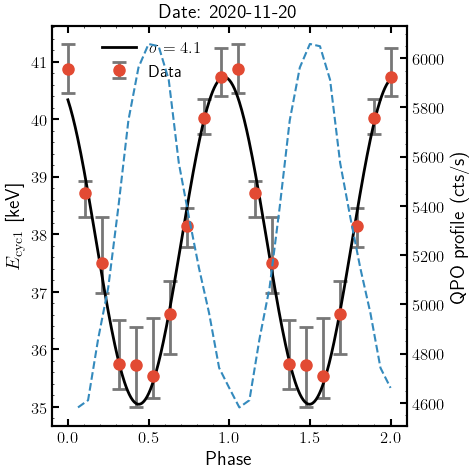

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.stats as stats

# 定义常数函数和正弦函数
def const_func(x, C):
    return C

def sin_func(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 数据
name0 = 'cyclabs1_E0'
x = np.linspace(0, 2, 20)
# x = np.linspace(0, 1, 10)
# 这里需要使用实际数据集 Para_all，如果没有数据，可以用随机数据代替
y1 = Para_all['%s' % name0].values
y1_errL = abs(Para_all['%s_Lerrs' % name0].values)
y1_errR = abs(Para_all['%s_Rerrs' % name0].values)
# 示例数据
# y1 = np.random.rand(20)  # 请用实际数据替换
# y1_errL = np.random.rand(20) * 0.1  # 请用实际数据替换
# y1_errR = np.random.rand(20) * 0.1  # 请用实际数据替换

y1 = np.hstack([y1, y1])
y1_errL = np.hstack([y1_errL, y1_errL])
y1_errR = np.hstack([y1_errR, y1_errR])

y_edge1_MaxTau = y1
y_err_lower_edge1_MaxTau = y1_errL
y_err_upper_edge1_MaxTau = y1_errR
y_err_edge1_MaxTau = (y_err_lower_edge1_MaxTau + y_err_upper_edge1_MaxTau) / 2

# 常数函数拟合
params_const, _ = curve_fit(const_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True)
y_fit_const = const_func(x, *params_const)
chi2_const = np.sum(((y_edge1_MaxTau - y_fit_const) / y_err_edge1_MaxTau) ** 2)
dof_const = len(y_edge1_MaxTau) - len(params_const)

# 正弦函数拟合
params_sin, params_covariance_sin = curve_fit(sin_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True, 
                                              p0=[40, 2*np.pi, 0, 0.4])
y_fit_sin = sin_func(x, *params_sin)
chi2_sin = np.sum(((y_edge1_MaxTau - y_fit_sin) / y_err_edge1_MaxTau) ** 2)
dof_sin = len(y_edge1_MaxTau) - len(params_sin)

# 使用更多的点使得拟合线条更平滑
x_smooth = np.linspace(0, 2, 400)
# x_smooth = np.linspace(0, 1, 400)
y_fit_smooth_sin = sin_func(x_smooth, *params_sin)

# 绘制拟合结果图像
fig, ax = plt.subplots(figsize=(5, 5))

# 绘制数据点和误差棒

ax.errorbar(x, y_edge1_MaxTau, yerr=[y_err_lower_edge1_MaxTau, y_err_upper_edge1_MaxTau], fmt='o', label='Data', color=colors['red'], ecolor=colors['gray'], elinewidth=2, capsize=5, capthick=2, markersize=8)
ax2 = ax.twinx()
# ax2.errorbar(phase_bins, profile/np.mean(profile), 
#                   drawstyle='steps-mid',color=colors['gray'],ecolor=colors['gray'])
ax2.errorbar(phase_bins, profile, 
                  fmt='--',color=colors['blue'],ecolor=colors['blue'],label='QPO profile')
ax2.set_ylabel('QPO profile (cts/s)')
# 添加 sigma 值的文本
textstr = r'$\sigma=%.1f$' % (z_score, )
#myvalue=3.9
#textstr = r'$\sigma=%.1f$' % (myvalue, )
# 绘制平滑后的拟合正弦波
ax.plot(x_smooth, y_fit_smooth_sin, label=textstr, color='black', linewidth=2)

# 设置文本框的外观
#props = dict(boxstyle='round', facecolor='white', alpha=0.5)
#ax.text(0.25, 0.95, textstr, transform=ax.transAxes, fontsize=14, verticalalignment='top')

# 设置标签和标题
# ax.set_xlabel('Phase', fontsize=14, fontweight='bold',fontname='Times New Roman')
# ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]', fontsize=14, fontweight='bold',fontname='Times New Roman')
ax.set_xlabel('Phase')
ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]')
# 显示图例
ax.legend(loc='upper left',bbox_to_anchor=(0.1, 1))

# 去掉网格
ax.grid(False)

# 调整刻度和刻度标签
# ax.spines['top'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
#ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('Date: 2020-11-20', fontsize=14, fontweight='bold',fontname='Times New Roman')
ax.set_title('Date: 2020-11-20')
# 美化图形外观
fig.tight_layout()
# 保存图像为PDF（如需要）
fig.savefig("20201120_cyclabs_sigma.pdf")
#fig.savefig("20201208_compmag_sigma.pdf")

In [17]:
print(np.mean(Para_all['%s' % name0].values)),print(np.max(Para_all['%s' % name0].values)),print(np.min(Para_all['%s' % name0].values))

43.50147
47.0869
39.6875


(None, None, None)

In [18]:
print([np.array(Para_all['%s' % name0].values)])
print([Para_all['%s_Lerrs' % name0].values,Para_all['%s_Rerrs' % name0].values])

[array([46.7069, 45.4768, 42.5435, 40.4825, 40.1051, 39.6875, 41.9164,
       44.3874, 46.6217, 47.0869])]
[array([0.39  , 0.7508, 0.5476, 0.6376, 1.3202, 0.4741, 0.7096, 0.6309,
       0.8281, 0.4714]), array([0.4239, 0.8707, 0.7481, 0.7042, 0.7574, 0.5779, 0.8007, 0.4619,
       0.3139, 0.3005])]


chi2 (constant model): 495.75
Degrees of freedom (constant model): 19
chi2 (sin model): 3.50
Degrees of freedom (sin model): 16
F value: 749.05
p value: 1.110223e-16
Sigma: 8.21
P-value: 1.110223e-16


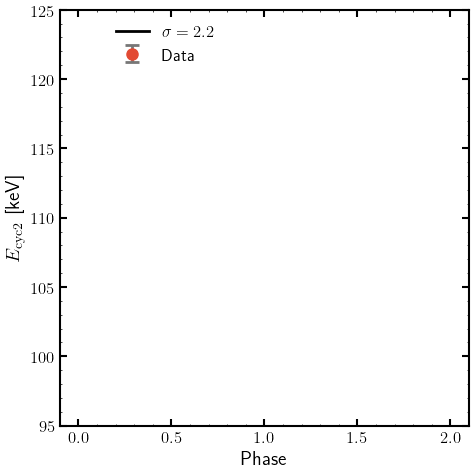

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.stats as stats

# 定义常数函数和正弦函数
def const_func(x, C):
    return C

def sin_func(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 数据
name0 = 'gabs1_LineE'
x = np.linspace(0, 2, 20)
#x = np.linspace(0, 1, 10)
# 这里需要使用实际数据集 Para_all，如果没有数据，可以用随机数据代替
y1 = Para_all['%s' % name0].values
y1_errL = abs(Para_all['%s_Lerrs' % name0].values)
y1_errR = abs(Para_all['%s_Rerrs' % name0].values)
# 示例数据
# y1 = np.random.rand(20)  # 请用实际数据替换
# y1_errL = np.random.rand(20) * 0.1  # 请用实际数据替换
# y1_errR = np.random.rand(20) * 0.1  # 请用实际数据替换

y1 = np.hstack([y1, y1])
y1_errL = np.hstack([y1_errL, y1_errL])
y1_errR = np.hstack([y1_errR, y1_errR])

y_edge1_MaxTau = y1
y_err_lower_edge1_MaxTau = y1_errL
y_err_upper_edge1_MaxTau = y1_errR
y_err_edge1_MaxTau = (y_err_lower_edge1_MaxTau + y_err_upper_edge1_MaxTau) / 2

# 常数函数拟合
params_const, _ = curve_fit(const_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True)
y_fit_const = const_func(x, *params_const)
chi2_const = np.sum(((y_edge1_MaxTau - y_fit_const) / y_err_edge1_MaxTau) ** 2)
dof_const = len(y_edge1_MaxTau) - len(params_const)

# 正弦函数拟合
params_sin, params_covariance_sin = curve_fit(sin_func, x, y_edge1_MaxTau, sigma=y_err_edge1_MaxTau, absolute_sigma=True, 
                                              p0=[40, 2*np.pi, 0, 0.4])
y_fit_sin = sin_func(x, *params_sin)
chi2_sin = np.sum(((y_edge1_MaxTau - y_fit_sin) / y_err_edge1_MaxTau) ** 2)
dof_sin = len(y_edge1_MaxTau) - len(params_sin)

# 计算 F 值
F_value = ((chi2_const - chi2_sin) / (dof_const - dof_sin)) / (chi2_sin / dof_sin)

# 计算 p 值
p_value = 1 - stats.f.cdf(F_value, dof_const - dof_sin, dof_sin)

# 输出结果
print(f"chi2 (constant model): {chi2_const:.2f}")
print(f"Degrees of freedom (constant model): {dof_const}")
print(f"chi2 (sin model): {chi2_sin:.2f}")
print(f"Degrees of freedom (sin model): {dof_sin}")
print(f"F value: {F_value:.2f}")
print(f"p value: {p_value:.6e}")  # 使用科学计数法显示非常小的p值

# 计算 Z 分数（标准差数）
z_score = stats.norm.ppf(1 - p_value)  # 使用 1 - p_value 计算Z分数

# 使用更多的点使得拟合线条更平滑
x_smooth = np.linspace(0, 2, 400)
#x_smooth = np.linspace(0, 1, 400)
y_fit_smooth_sin = sin_func(x_smooth, *params_sin)

# 绘制拟合结果图像
fig, ax = plt.subplots(figsize=(5, 5))

# 绘制数据点和误差棒
ax.errorbar(x, y_edge1_MaxTau, yerr=[y_err_lower_edge1_MaxTau, y_err_upper_edge1_MaxTau], fmt='o', label='Data', color=colors['red'], ecolor=colors['gray'], elinewidth=2, capsize=5, capthick=2, markersize=8)

# 添加 sigma 值的文本
#textstr = r'$\sigma=%.2f$' % (z_score, )
myvalue=2.2
textstr = r'$\sigma=%.1f$' % (myvalue, )
# 绘制平滑后的拟合正弦波
ax.plot(x_smooth, y_fit_smooth_sin, label=textstr, color='black', linewidth=2)

# 设置文本框的外观
#props = dict(boxstyle='round', facecolor='white', alpha=0.5)
#ax.text(0.25, 0.95, textstr, transform=ax.transAxes, fontsize=14, verticalalignment='top')

# 设置标签和标题
# ax.set_xlabel('Phase', fontsize=14, fontweight='bold',fontname='Times New Roman')
# ax.set_ylabel(r'$E_{\rm cyc1}$ [keV]', fontsize=14, fontweight='bold',fontname='Times New Roman')
ax.set_xlabel('Phase')
ax.set_ylabel(r'$E_{\rm cyc2}$ [keV]')
# 显示图例
ax.legend(loc='upper left',bbox_to_anchor=(0.1, 1))
ax.set_ylim(95,125)
# 去掉网格
ax.grid(False)

# 调整刻度和刻度标签
# ax.spines['top'].set_linewidth(2)
# ax.spines['right'].set_linewidth(2)
# ax.spines['bottom'].set_linewidth(2)
# ax.spines['left'].set_linewidth(2)
#ax.tick_params(axis='both', which='major', labelsize=14)
#ax.set_title('Date: 2020-11-20', fontsize=14, fontweight='bold',fontname='Times New Roman')
#ax.set_title('Date: 2020-11-20')
# 美化图形外观
fig.tight_layout()
# 保存图像为PDF（如需要）
#fig.savefig("20201120_fdcut_sigma2.pdf")
print(f"Sigma: {z_score:.2f}")
print(f"P-value: {p_value:.6e}")